In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
# Load cleaned data
df = pd.read_csv(r"C:\Users\HP\Desktop\RealEstatePricePrediction\data\processed\featured_data.csv")

In [4]:
# Load the saved model
with open(r"C:\Users\HP\Desktop\RealEstatePricePrediction\models\best_model.pkl", "rb") as f:
    model = pickle.load(f)

In [5]:
# Load column names
with open(r"C:\Users\HP\Desktop\RealEstatePricePrediction\models\columns.json", "r") as f:
    columns = json.load(f)["data_columns"]

In [6]:
print("Data shape:", df.shape)
print("Total columns:", len(columns))

Data shape: (8917, 181)
Total columns: 180


In [7]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["price"])
y = df["price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

y_pred = model.predict(x_test)

print("First 5 actual prices:", y_test.values[:5])
print("First 5 predicted prices:", np.round(y_pred[:5], 2))

First 5 actual prices: [ 99.39  36.    61.26 116.    30.27]
First 5 predicted prices: [108.7   19.61  80.7  122.87  16.09]


In [8]:
#calculating errors
mae= mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("MAE:",round(mae,2))
print("MSE:",round(mse,2))
print("RMSE:",round(rmse,2))
print("R2:",round(r2,4))


MAE: 12.03
MSE: 356.48
RMSE: 18.88
R2: 0.9216


- on average our model is off by 12 lakhs per prediction
- our model explains 92.16% of price variation
- RMSE is higher than MAE, beecause it penalizes large errors  modre

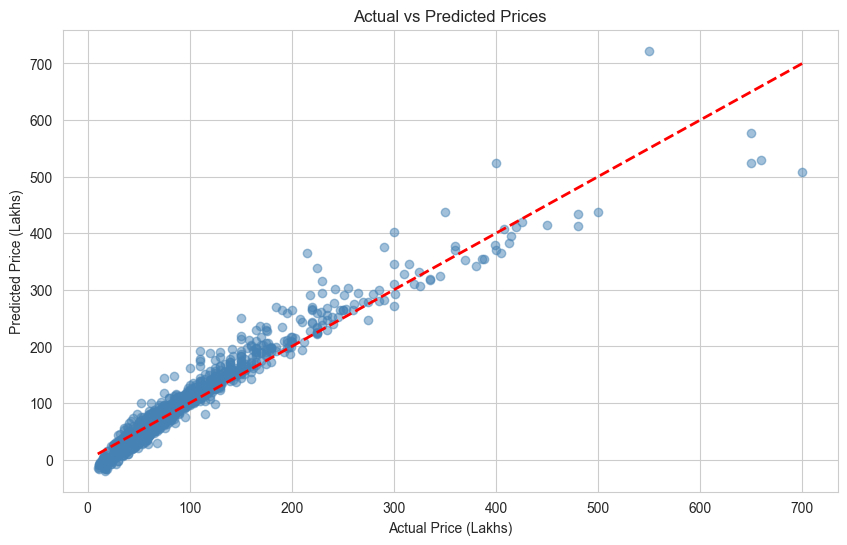

In [9]:
#scatter plot 
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=2, linestyle="--")
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted Prices")
plt.show()

- model predicts cheap and mid range houses well
- large errors on expensive houses above 200 lakhs
- a few negative predictions 

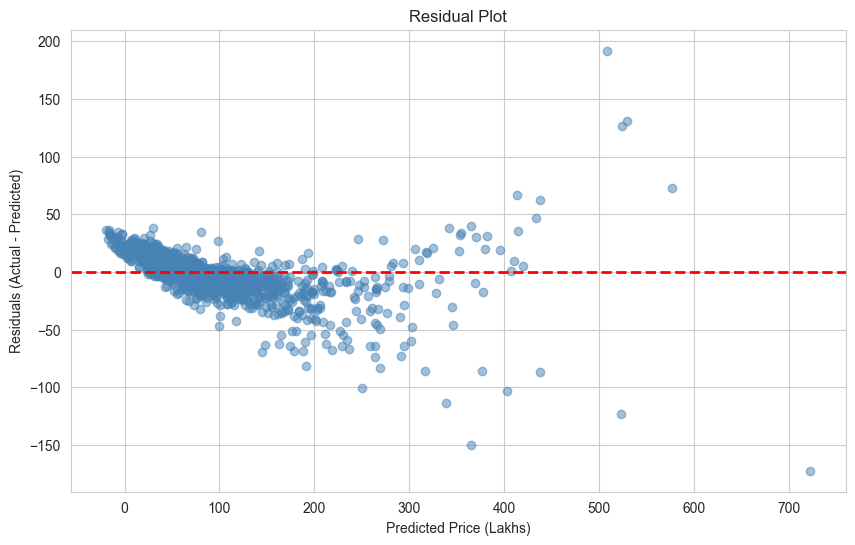

In [10]:
#Residual plots
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color="steelblue")
plt.axhline(y=0, color="red", linewidth=2, linestyle="--")
plt.xlabel("Predicted Price (Lakhs)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

- since red line is at 0, it is perfect prediction
- model is very accurate for cheaper houses
- errors spread wider as price increases - heteroscedasticity present
- model performs best on 0-200 lakh range

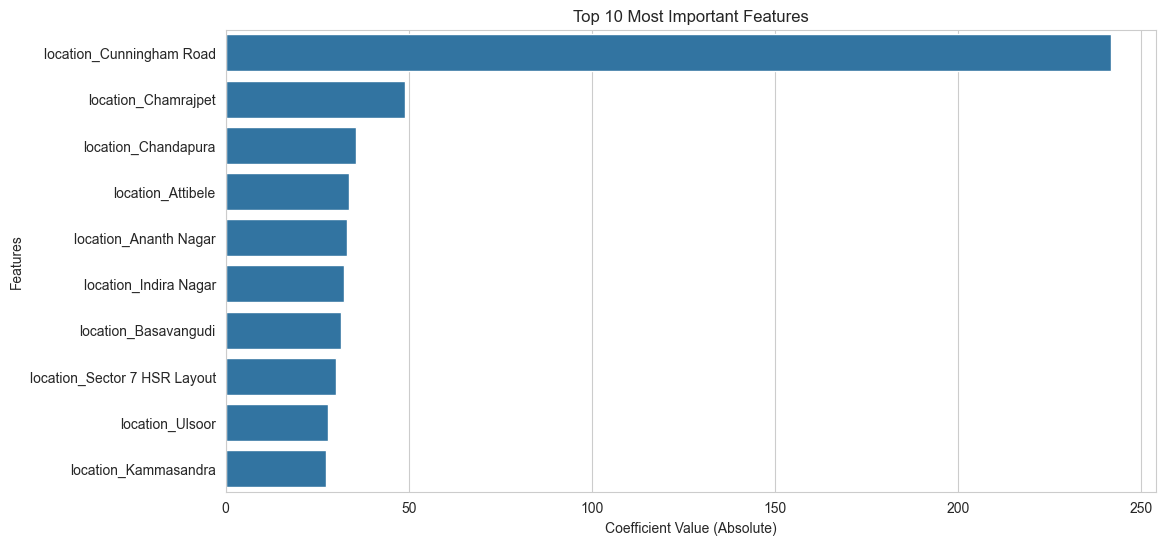

In [11]:
#feature importance
importance = pd.Series(np.abs(model.coef_), index=x.columns)
top_features = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 Most Important Features")
plt.xlabel("Coefficient Value (Absolute)")
plt.ylabel("Features")
plt.show()

In [12]:
#custom prediction
def predict_price(location, sqft, bath, bhk):
    loc_index = np.where(np.array(columns) == "location_" + location)[0]
    
    x = np.zeros(len(columns))
    x[columns.index("total_sqft")] = sqft
    x[columns.index("bath")] = bath
    x[columns.index("bhk")] = bhk
    x[columns.index("price_per_sqft")] = df["price_per_sqft"].mean()
    
    if len(loc_index) > 0:
        x[loc_index[0]] = 1
    
    return round(model.predict([x])[0], 2)

print(predict_price("Whitefield", 1000, 2, 2))
print(predict_price("Indiranagar", 1000, 2, 2))
print(predict_price("Cunningham Road", 1000, 2, 2))

53.42
58.4
300.21


c:\Users\HP\Desktop\RealEstatePricePrediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\HP\Desktop\RealEstatePricePrediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\HP\Desktop\RealEstatePricePrediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


- same house (1000sqft,2bathrooms,2BHK) ind iff locations:
    - whitefield: 53.42 lakhs
    - Indiranagar: 58.4 lakhs
    - Cunningham Road: 300.21 lakhs
- diference is just due to location- this confirms location is the most important feature

Feature importance saved!


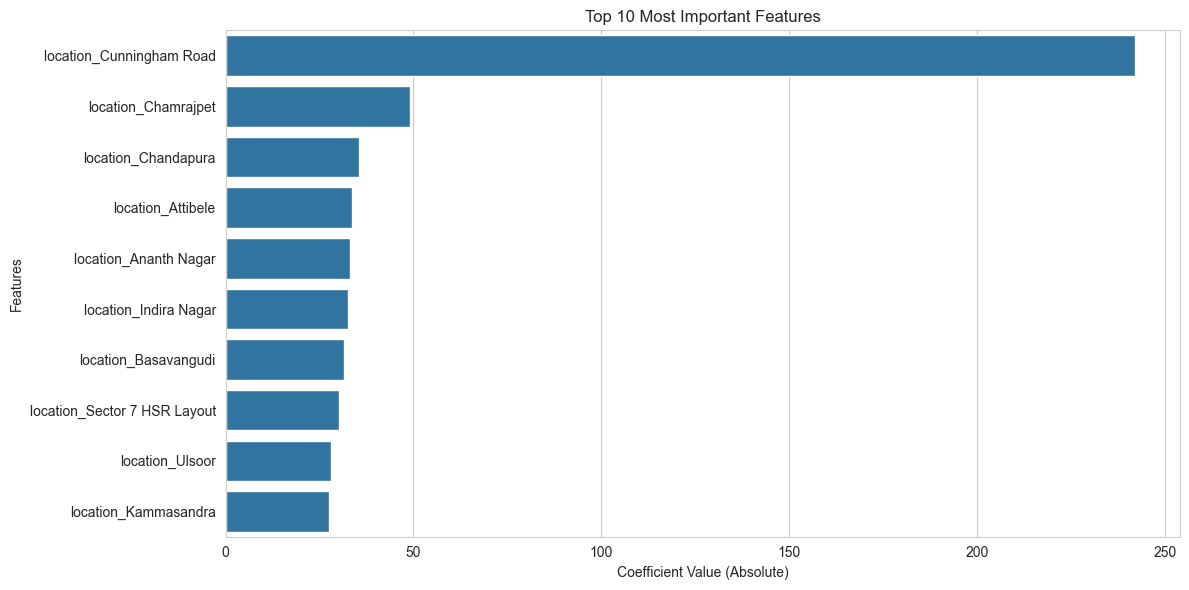

In [13]:
importance = pd.Series(np.abs(model.coef_), index=x.columns)
top_features = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 Most Important Features")
plt.xlabel("Coefficient Value (Absolute)")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig(r"C:\Users\HP\Desktop\RealEstatePricePrediction\reports\feature_importance.png")
print("Feature importance saved!")